In [1]:
# !uv run python -m ensurepip --upgrade
# !python -m spacy download en_core_web_sm

In [2]:
%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = "retina"

In [3]:
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_style("whitegrid")

In [5]:
from src.common import SV_COL
from src.plots import (
    plot_attribution_trend,
    plot_derivative,
    plot_importance_cumsum_and_derivative,
    plot_token_count_distribution,
)
from src.sgpa import CASES, FIGURES_DIR, STATS_DIR, load_experiments_results
from src.stats import (
    perform_advanced_ttest,
)
from src.transformations import calculate_normalized_entropy, normalize_lengths

# Tests and preparation

In [6]:
df = pd.DataFrame()
for case in ["SM2S", "SF2S"]:
    if case not in CASES:
        raise ValueError(f"Unsupported case: {case}")

    case_df = load_experiments_results(case)
    case_df["mode"] = case
    df = pd.concat([df, case_df], ignore_index=True)

In [7]:
df["sv"] = df["conversation"].apply(lambda x: x[1][1]["shap_values"])
df["sv"] = df["sv"].apply(lambda sv: [token for token in sv if token is not None])
df["count_explainable_tokens"] = df["sv"].apply(len)
df["sgpa"] = pd.Categorical(df["sgpa"], categories=[True, False], ordered=True)
df["mode"] = pd.Categorical(df["mode"], categories=["SM2S", "SF2S"], ordered=True)

df = df[
    [
        "row_index",
        "sv",
        "count_explainable_tokens",
        "mode",
        "neyman_steps",
        "n_calls",
        "runtime_sec",
        "language",
        "sgpa",
    ]
]

results_df = df.explode("sv").reset_index(drop=True)
results_df["sv"] = results_df["sv"].astype(float)

# Data preprocessing

## Data distributions

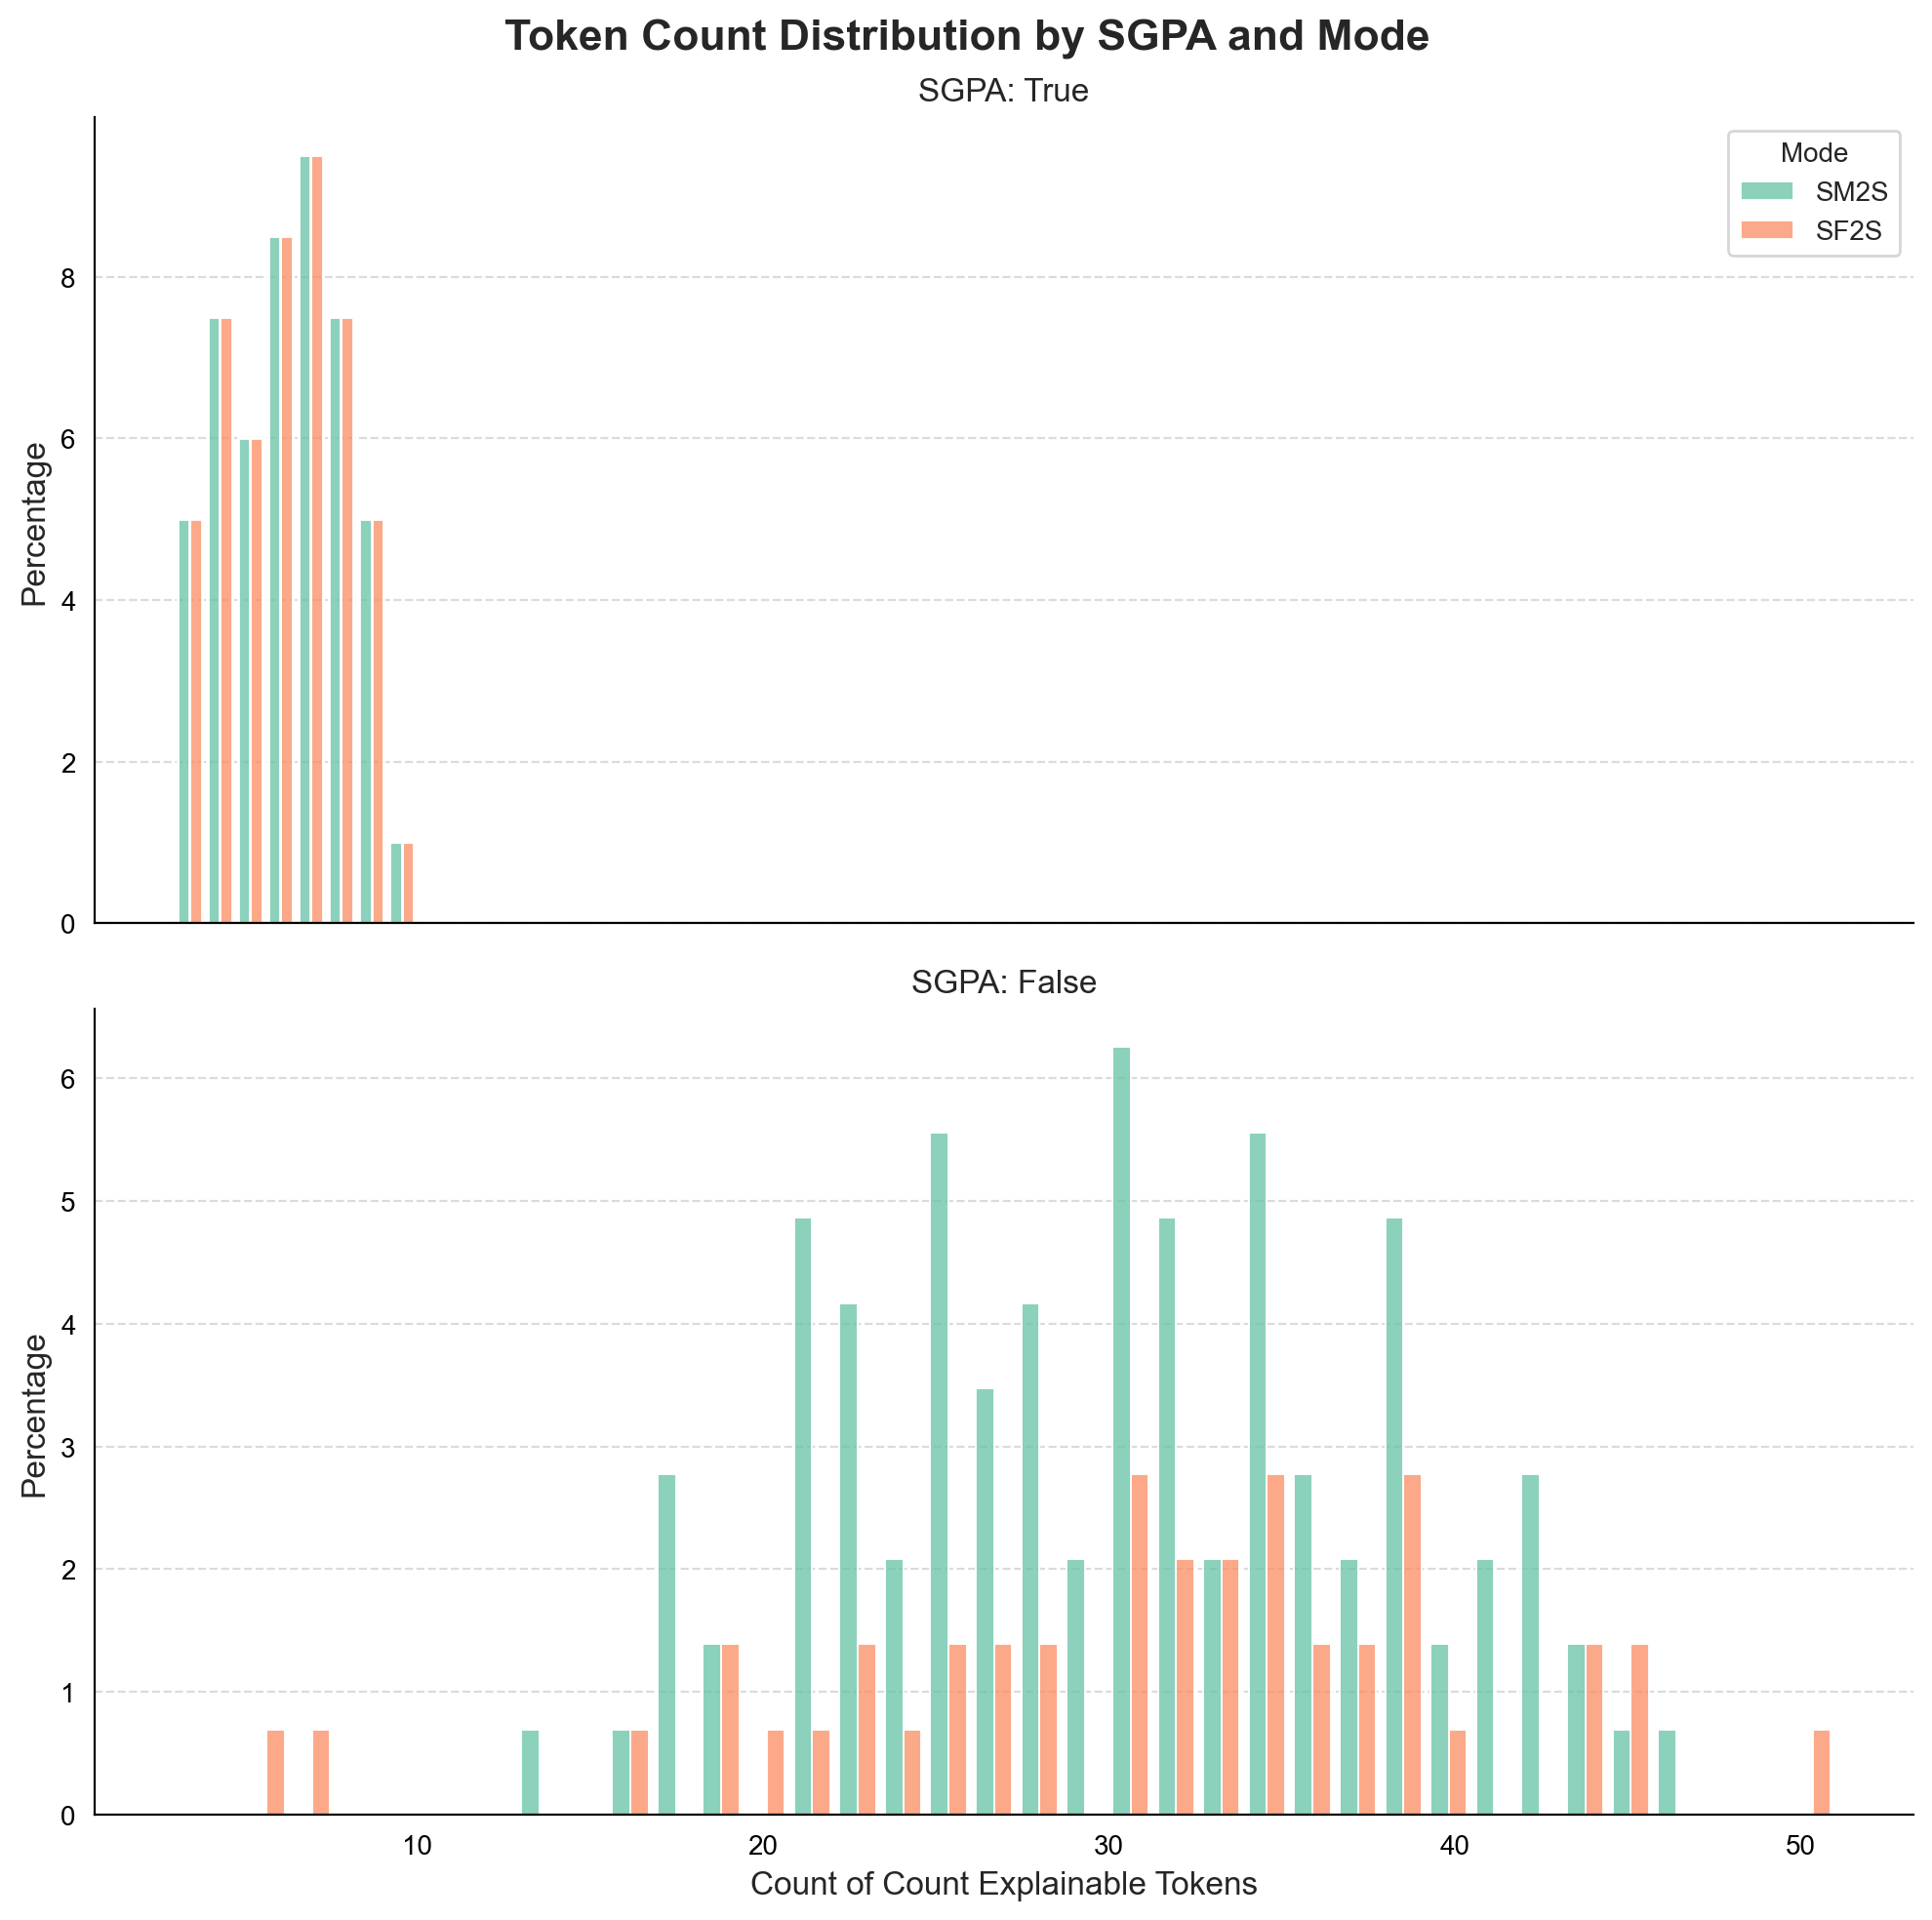

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 5 * 2), sharex=True)

for i, sgpa in enumerate([True, False]):
    sgpa_df = df[df["sgpa"] == sgpa]
    plot_token_count_distribution(
        sgpa_df.rename(columns={"mode": "Mode"}),
        column="count_explainable_tokens",
        plot_ax=axes[i],
        hue="Mode",
        legend=i == 0,
    )
    axes[i].set_title(f"SGPA: {sgpa}")

fig.suptitle("Token Count Distribution by SGPA and Mode", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/token_count_distribution.png", bbox_inches="tight", dpi=300)

In [9]:
neyman_steps_distribution = df.groupby(["sgpa", "mode"])["neyman_steps"].value_counts(normalize=True)
neyman_steps_distribution.unstack()

neyman_steps         1         2
sgpa  mode                      
True  SM2S    0.370000  0.630000
      SF2S    0.370000  0.630000
False SM2S    0.000000  1.000000
      SF2S    0.022727  0.977273

In [10]:
summary_stats = df.groupby(["sgpa", "mode"])[["n_calls", "runtime_sec"]].agg(["describe"])
summary_stats.stack(level=0).unstack(level=1)

describe                                                \
                     count                mean                       std   
mode                  SM2S   SF2S         SM2S         SF2S         SM2S   
sgpa                                                                       
True  n_calls        100.0  100.0    59.420000    59.320000    53.608604   
      runtime_sec    100.0  100.0    67.532749    66.081696    56.420089   
False n_calls        100.0   44.0  2365.760000  2552.136364  1179.067095   
      runtime_sec    100.0   44.0  1696.491648  1819.882646   802.612282   

                                                                    \
                                       min                     25%   
mode                      SF2S        SM2S       SF2S         SM2S   
sgpa                                                                 
True  n_calls        53.650737    6.000000   6.000000    15.500000   
      runtime_sec    55.220210    4.848415   4.747431    17.166915   
False n_calls      1417.997828  414.000000  30.000000  1451.000000   
      runtime_sec   976.224329  328.720241  20.785732  1070.193724   

                                                                       \
                                        50%                       75%   
mode                      SF2S         SM2S         SF2S         SM2S   
sgpa                                                                    
True  n_calls        14.000000    30.000000    30.000000   120.000000   
      runtime_sec    16.182326    43.832544    43.425780   125.736116   
False n_calls      1555.000000  2177.000000  2480.000000  3173.500000   
      runtime_sec  1110.756613  1568.769281  1805.484426  2260.611348   

                                                          
                                        max               
mode                      SF2S         SM2S         SF2S  
sgpa                                                      
True  n_calls       118.000000   202.000000   200.000000  
      runtime_sec   123.527769   199.532876   197.016598  
False n_calls      3364.000000  5552.000000  6624.000000  
      runtime_sec  2377.974401  3742.922515  4536.898677

# Analysis

## Cumulative sum

Let's also have a look on how the cumulative sum curves look like for all samples.

In [11]:
df["sv_cumsum"] = df[SV_COL].apply(np.cumsum)
cumsums = df.groupby("row_index", group_keys=False)[["sgpa", "mode", "row_index", "sv_cumsum"]].apply(normalize_lengths)

In [12]:
plot_df = cumsums.explode("sv_cumsum").reset_index(drop=True)
plot_df["time (tokens)"] = plot_df.groupby(["sgpa", "mode", "row_index"]).cumcount()

plot_df["sv_cumsum"] = plot_df["sv_cumsum"].astype(float)
plot_df["sv_derivative"] = plot_df.groupby(["sgpa", "mode", "row_index"])["sv_cumsum"].diff().fillna(0)

In [13]:
sns.set_theme(style="white")

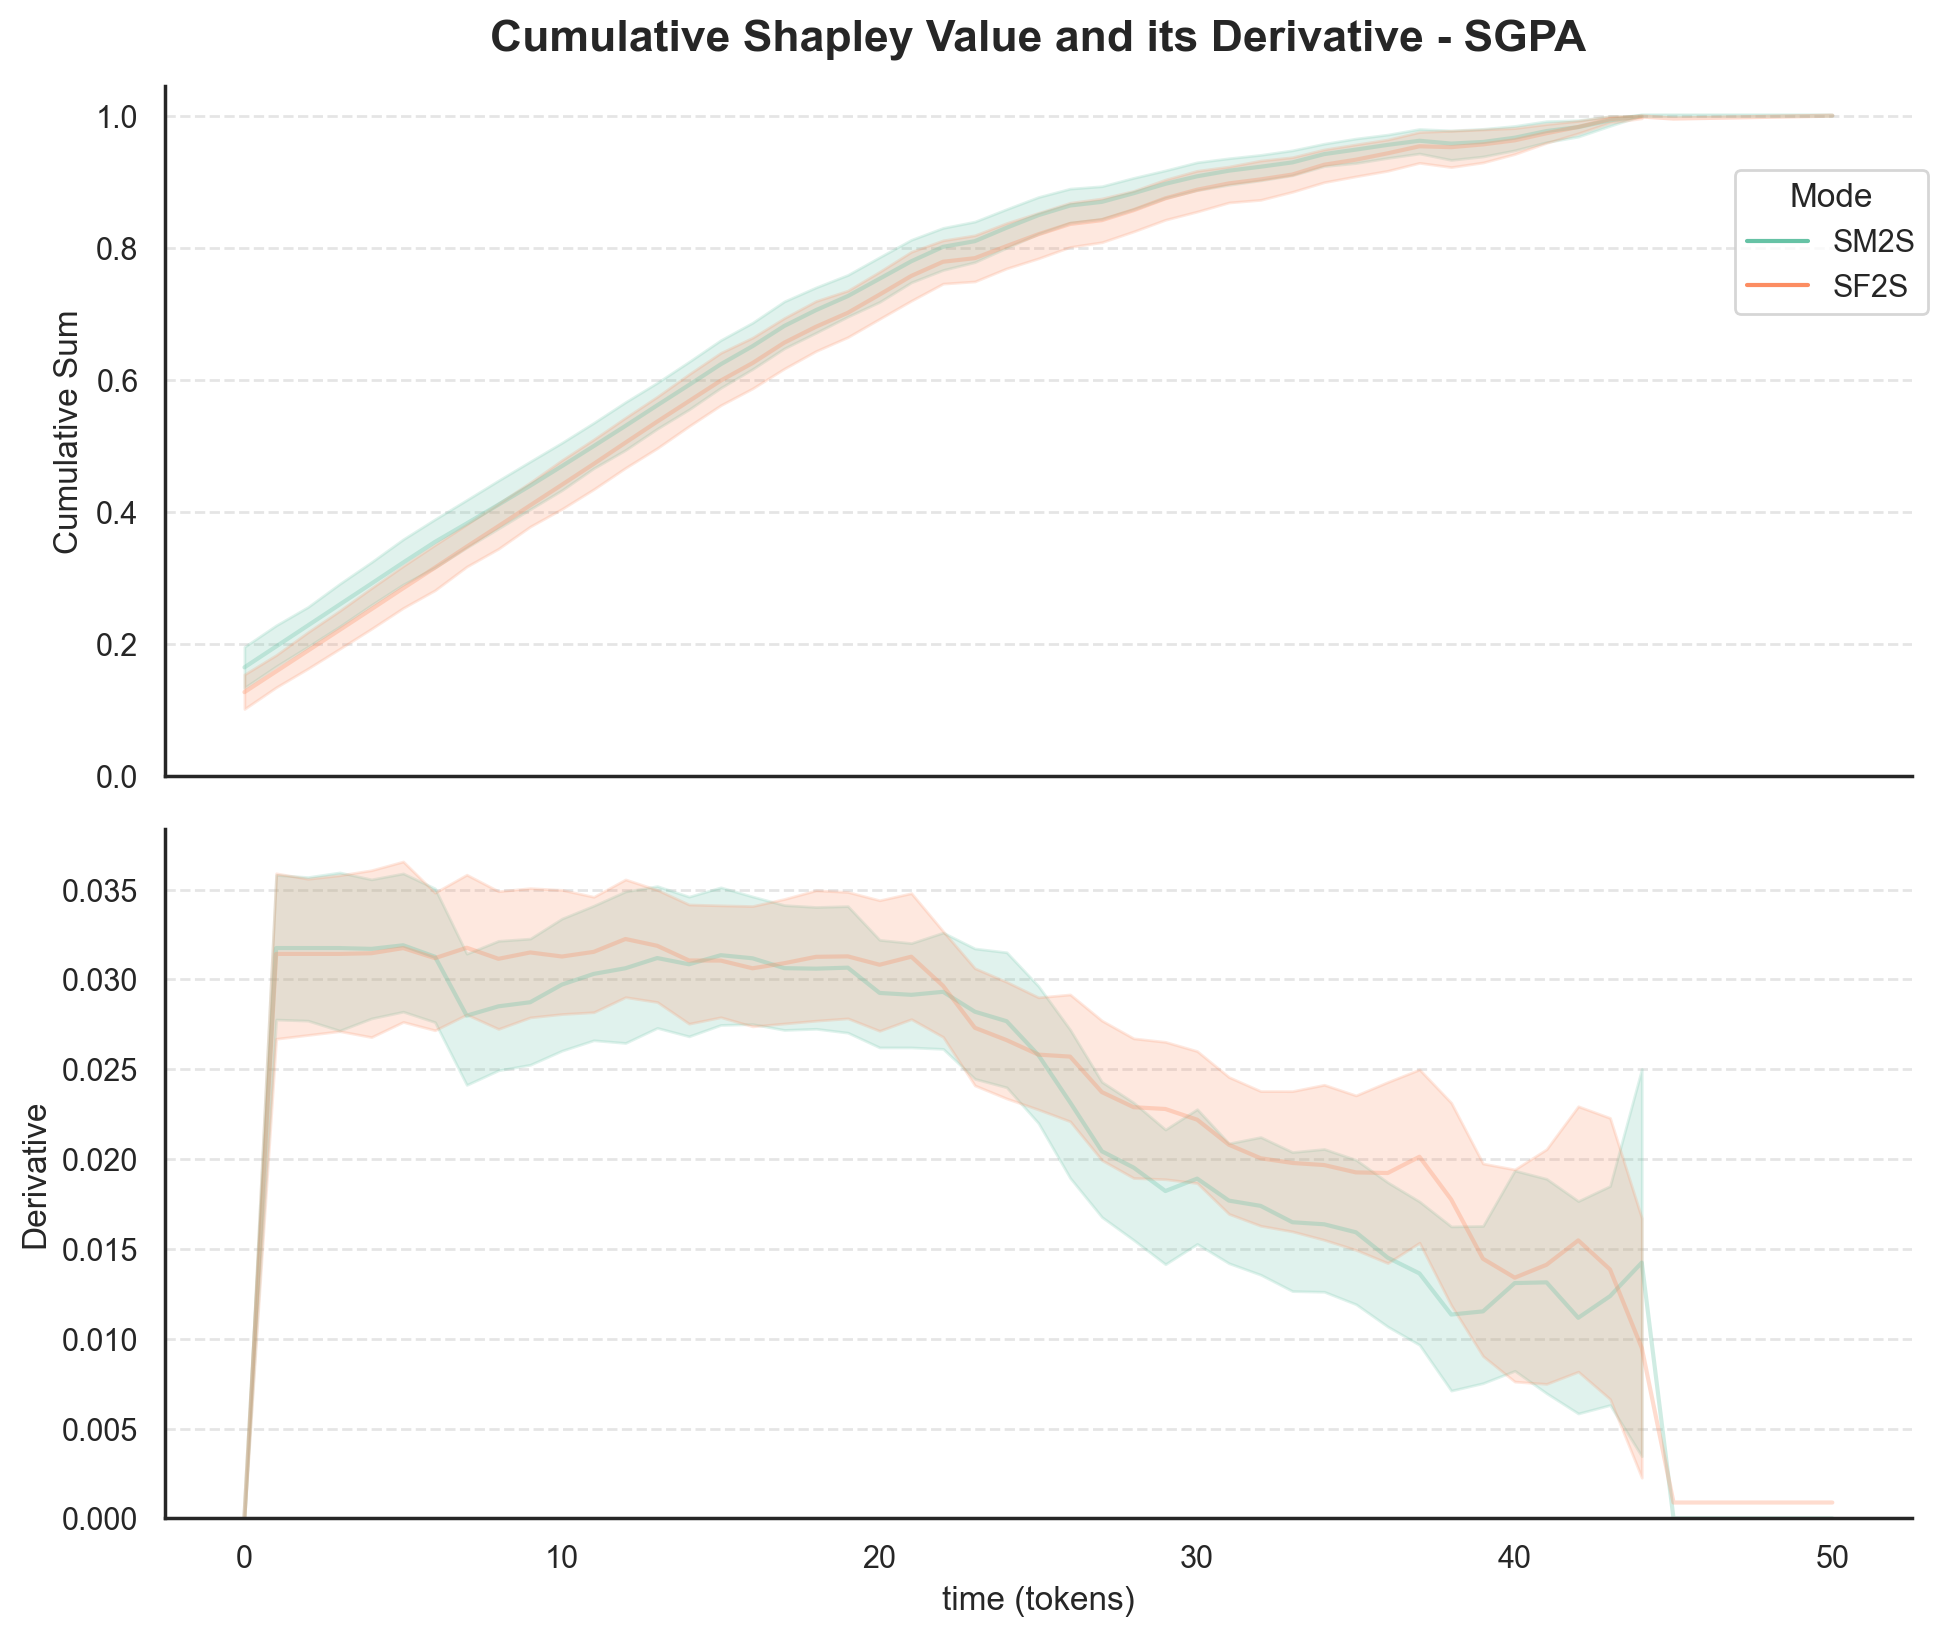

In [14]:
plot_importance_cumsum_and_derivative(plot_df[plot_df["sgpa"]])
plt.title("Cumulative Shapley Value and its Derivative - SGPA", fontsize=16, fontweight="bold", pad=280)
plt.savefig(f"{FIGURES_DIR}/cumulative_shapley_and_derivative_1.png", bbox_inches="tight", dpi=300)

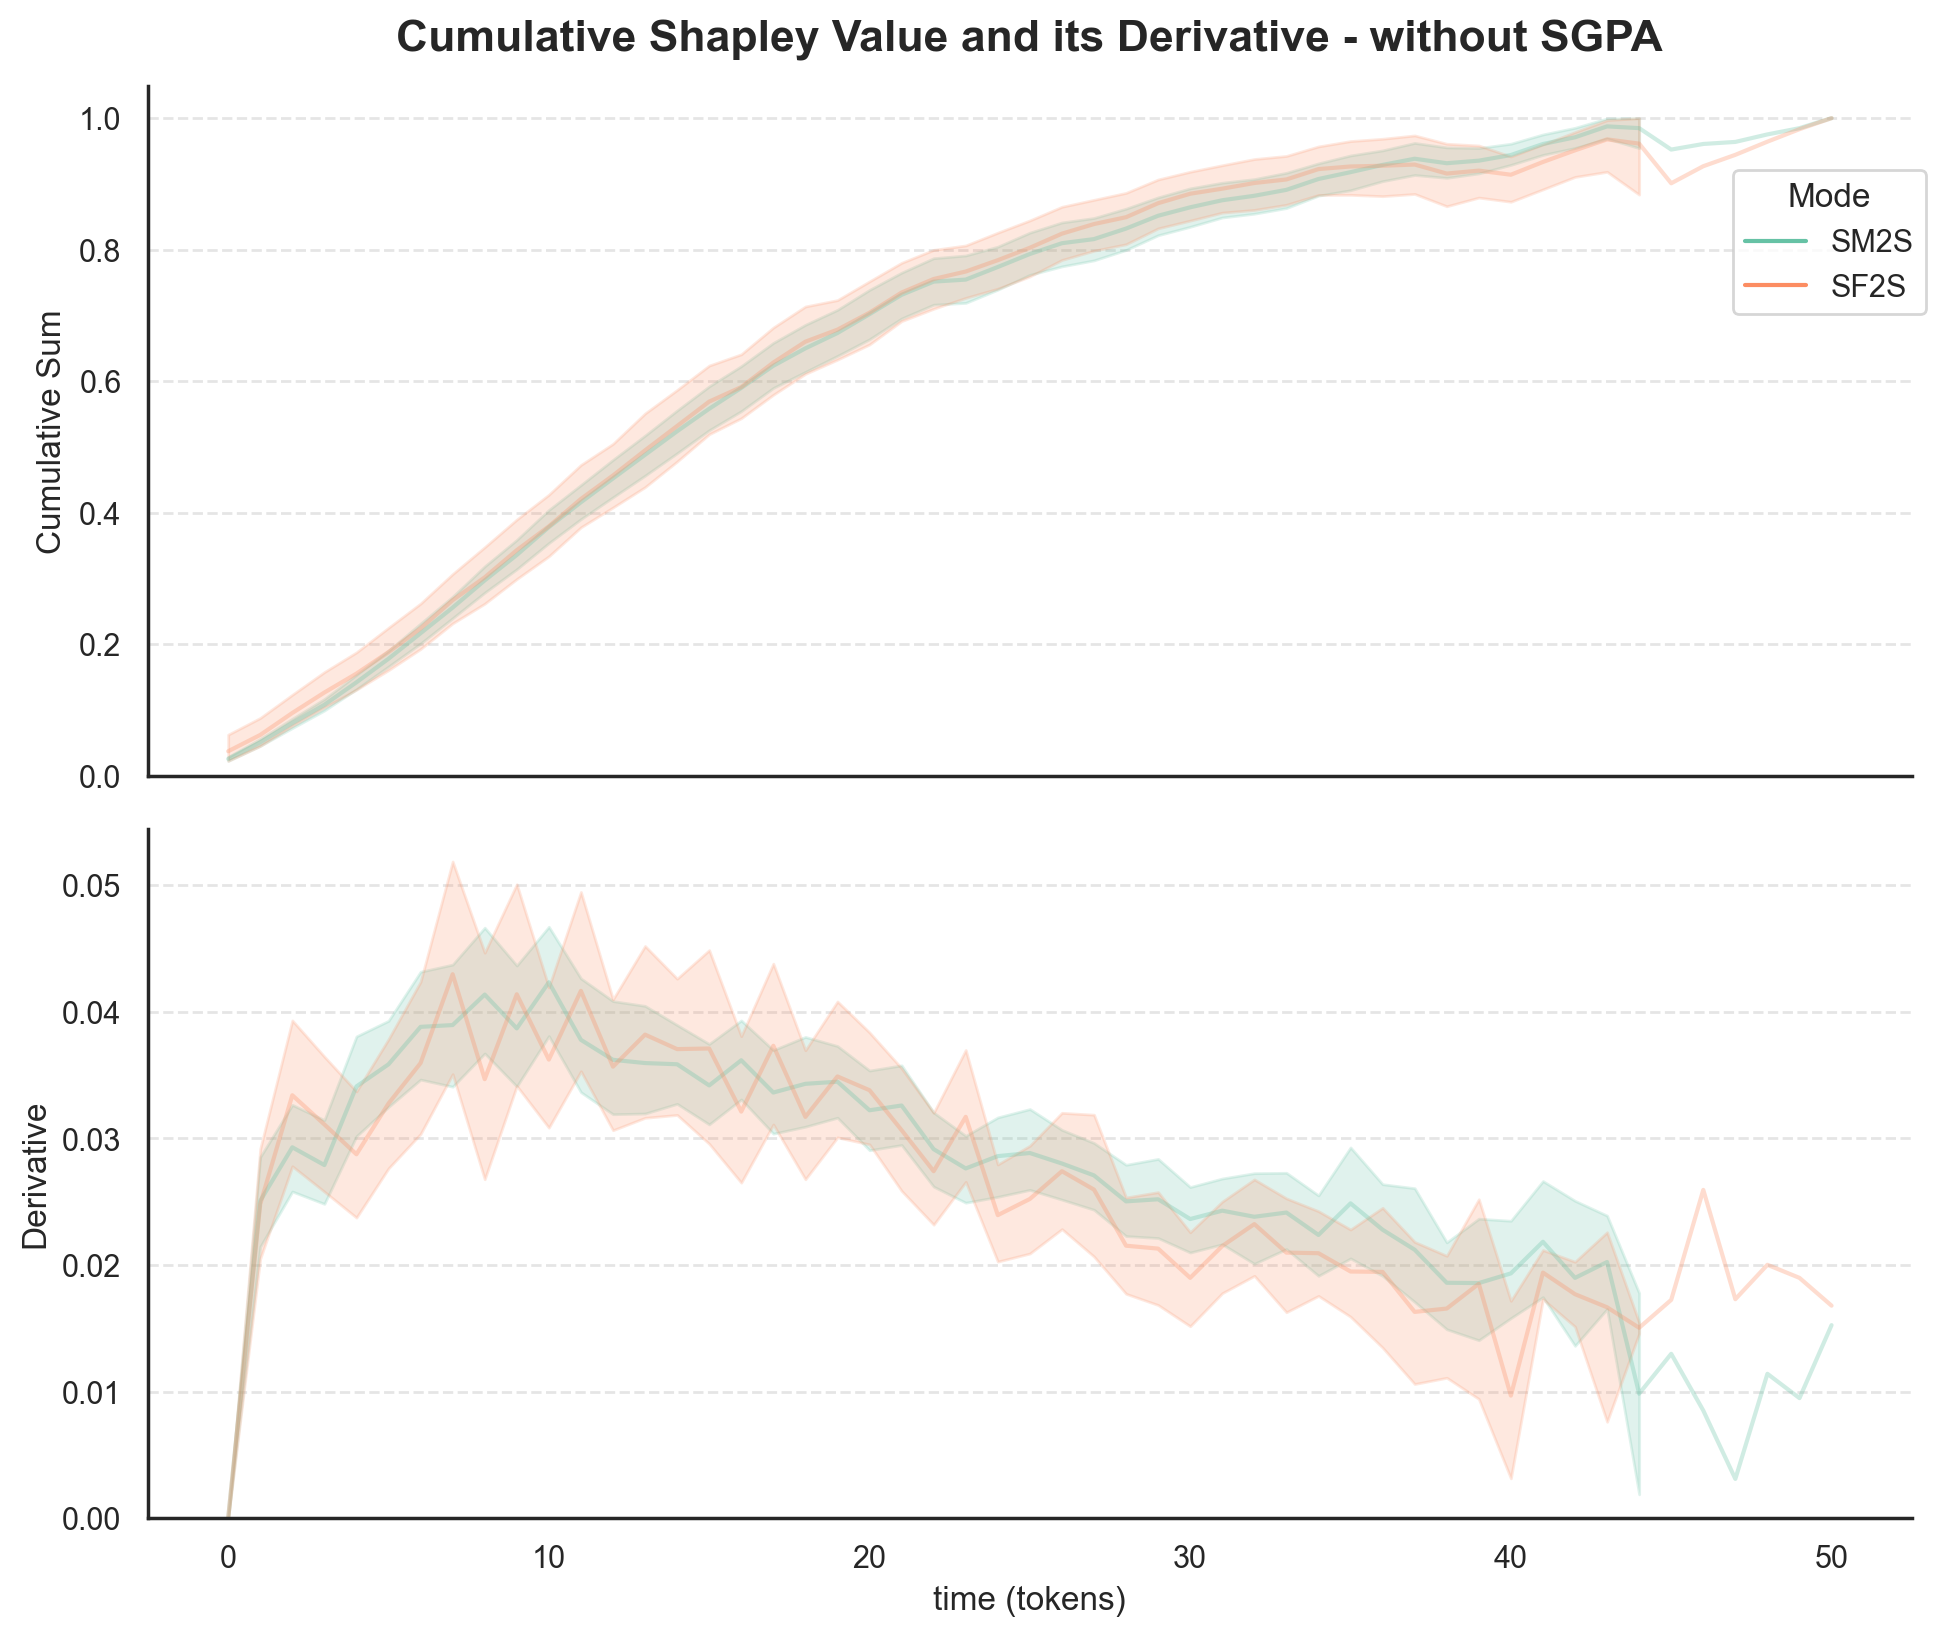

In [ ]:
plot_importance_cumsum_and_derivative(
    plot_df[plot_df["sgpa"] == False]  # noqa: E712 # pylint: disable=singleton-comparison
)  # noqa: E712 # pylint: disable=singleton-comparison
plt.title("Cumulative Shapley Value and its Derivative - without SGPA", fontsize=16, fontweight="bold", pad=280)
plt.savefig(f"{FIGURES_DIR}/cumulative_shapley_and_derivative_2.png", bbox_inches="tight", dpi=300)

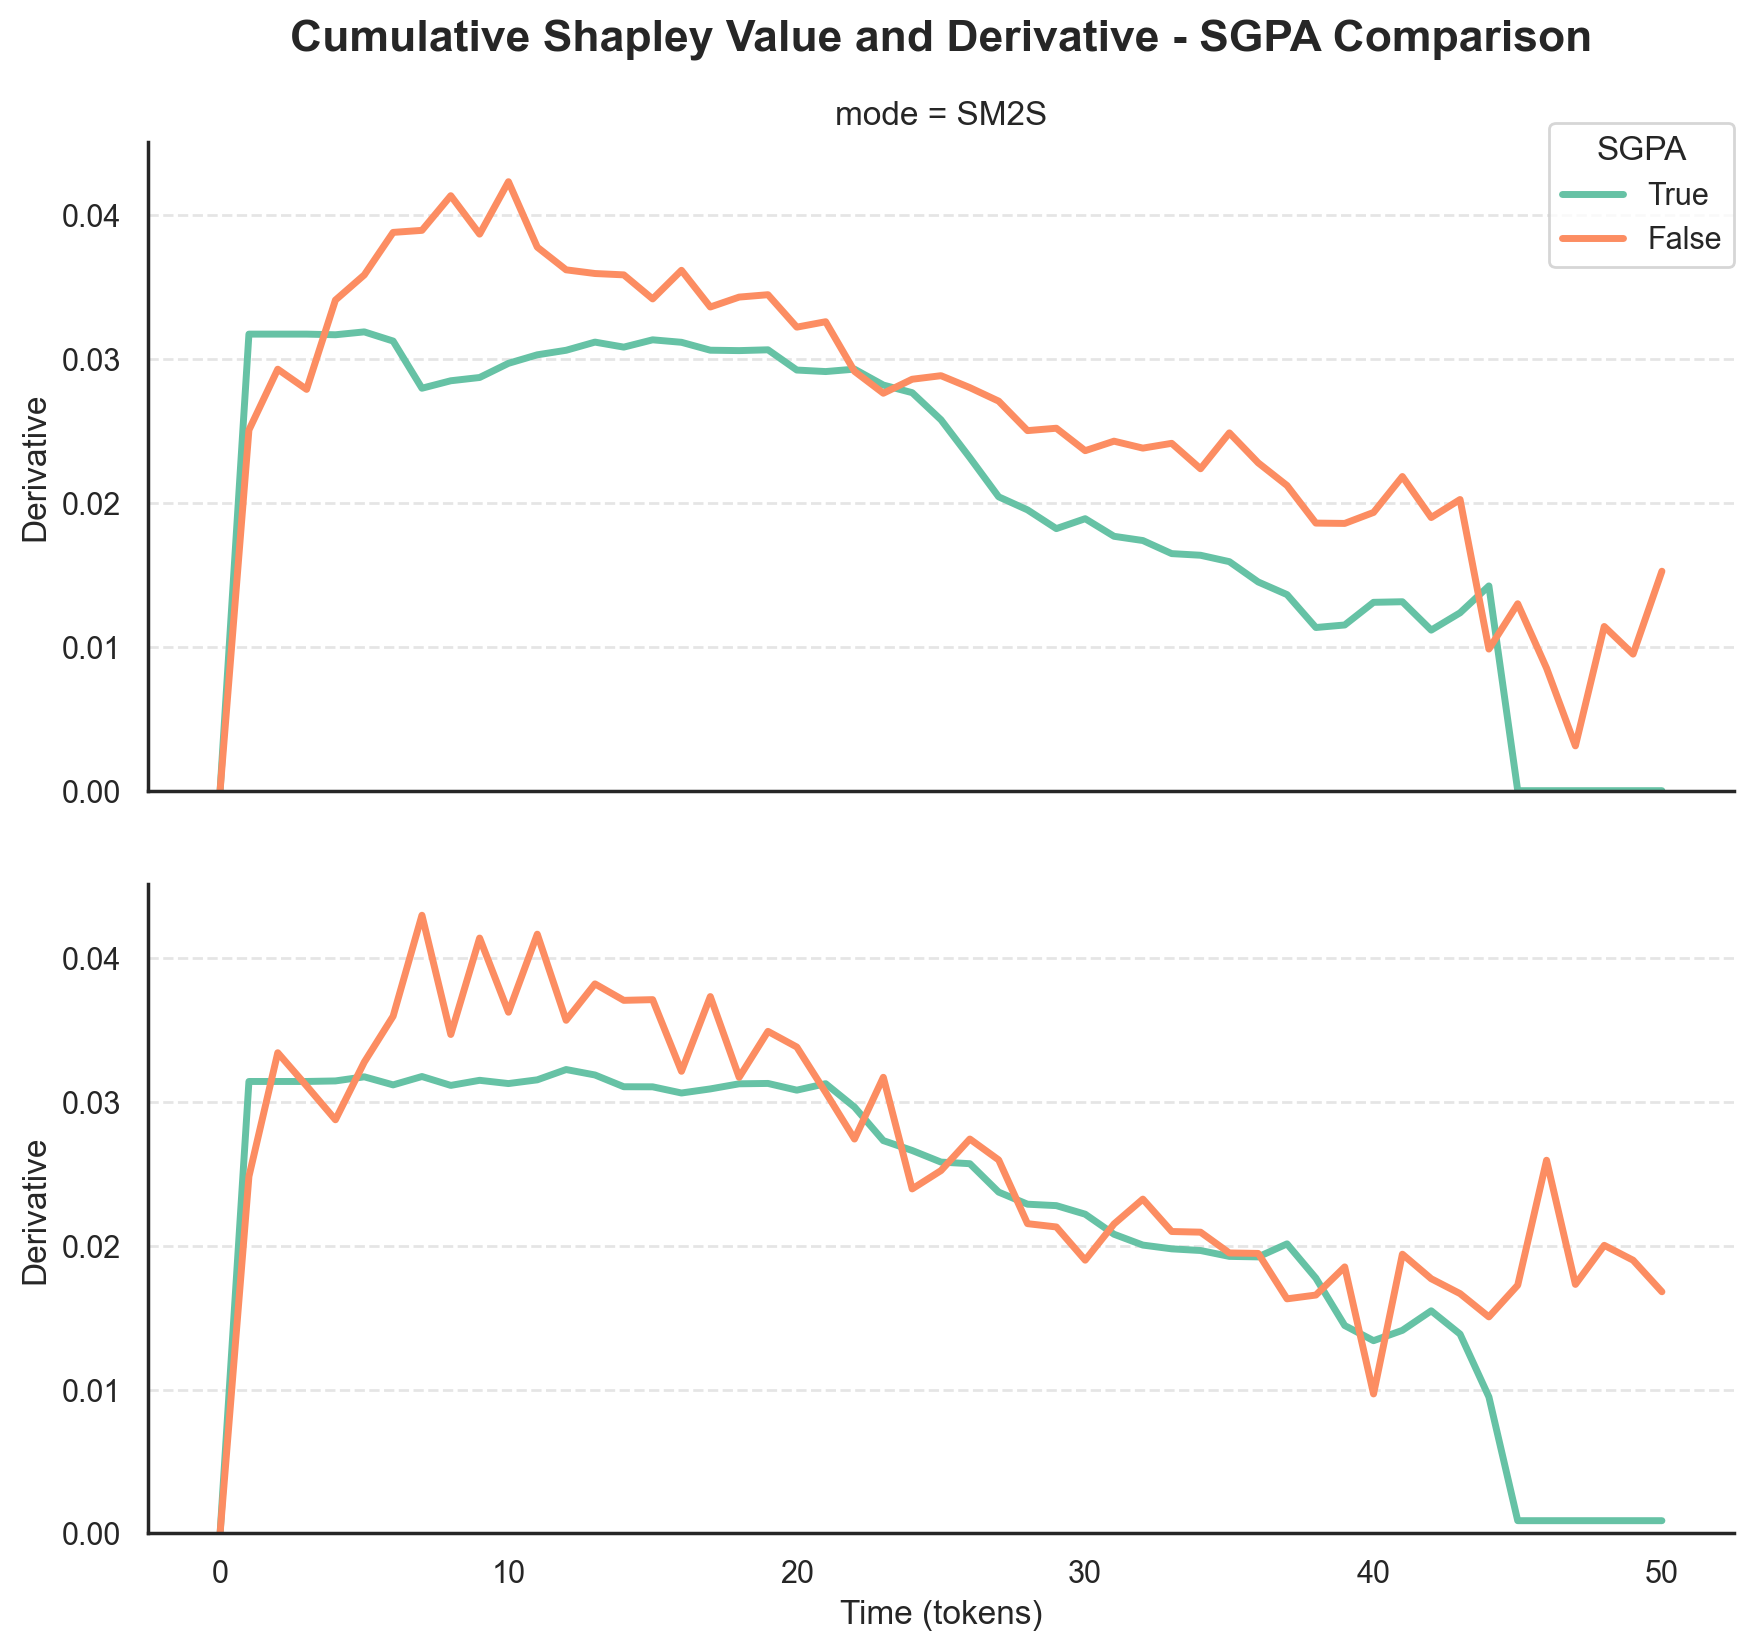

In [16]:
plot_derivative(plot_df.rename(columns={"sgpa": "SGPA"}), errorbar=None, alpha=1.0, linewidth=2.5, hue="SGPA")
plt.title("Cumulative Shapley Value and Derivative - SGPA Comparison", fontsize=16, fontweight="bold", pad=300)
plt.savefig(f"{FIGURES_DIR}/cumulative_shapley_and_derivative_3.png", bbox_inches="tight", dpi=300)

## General tests

Do Shapley values differ significantly?

In [ ]:
def recolumnize(_df: pd.DataFrame) -> pd.DataFrame:
    """Recolumnize Mode and Language columns from tuples."""
    _df["Sgpa_1"] = _df["Mode_1"].apply(lambda x: x[1] if isinstance(x, tuple) else x)
    _df["Sgpa_2"] = _df["Mode_2"].apply(lambda x: x[1] if isinstance(x, tuple) else x)
    _df["Mode_1"] = _df["Mode_1"].apply(lambda x: x[0] if isinstance(x, tuple) else x)
    _df["Mode_2"] = _df["Mode_2"].apply(lambda x: x[0] if isinstance(x, tuple) else x)
    return _df


def filter_results(_df: pd.DataFrame) -> pd.DataFrame:
    """Filter results to only significant adjusted p-values."""
    return _df[_df["Significant_Adj"]][
        ["metric", "Sgpa_1", "Sgpa_2", "Mode_1", "Mode_2", "P_Value", "Significant_Adj"]
    ].sort_values(by=["metric", "Sgpa_1", "Sgpa_2", "Mode_1", "Mode_2"])

In [18]:
results = perform_advanced_ttest(
    results_df,
    grp_by_cols=["row_index", "mode", "sgpa"],
    value_col=SV_COL,
    unstack=["mode", "sgpa"],
)

results = recolumnize(results)
results.to_csv(f"{STATS_DIR}/mean_ttest_results.csv")
results = filter_results(results)

In [19]:
results

,metric,Sgpa_1,Sgpa_2,Mode_1,Mode_2,P_Value,Significant_Adj
26,entropy,False,True,SM2S,SF2S,<0.01,True
28,entropy,True,False,SF2S,SF2S,<0.01,True
25,entropy,True,False,SM2S,SF2S,<0.01,True
23,entropy,True,False,SM2S,SM2S,<0.01,True
8,gini,False,True,SM2S,SF2S,<0.01,True
5,gini,True,False,SM2S,SM2S,<0.01,True
20,max,False,True,SM2S,SF2S,<0.01,True
22,max,True,False,SF2S,SF2S,<0.01,True
19,max,True,False,SM2S,SF2S,<0.01,True
17,max,True,False,SM2S,SM2S,<0.01,True


## Entropy

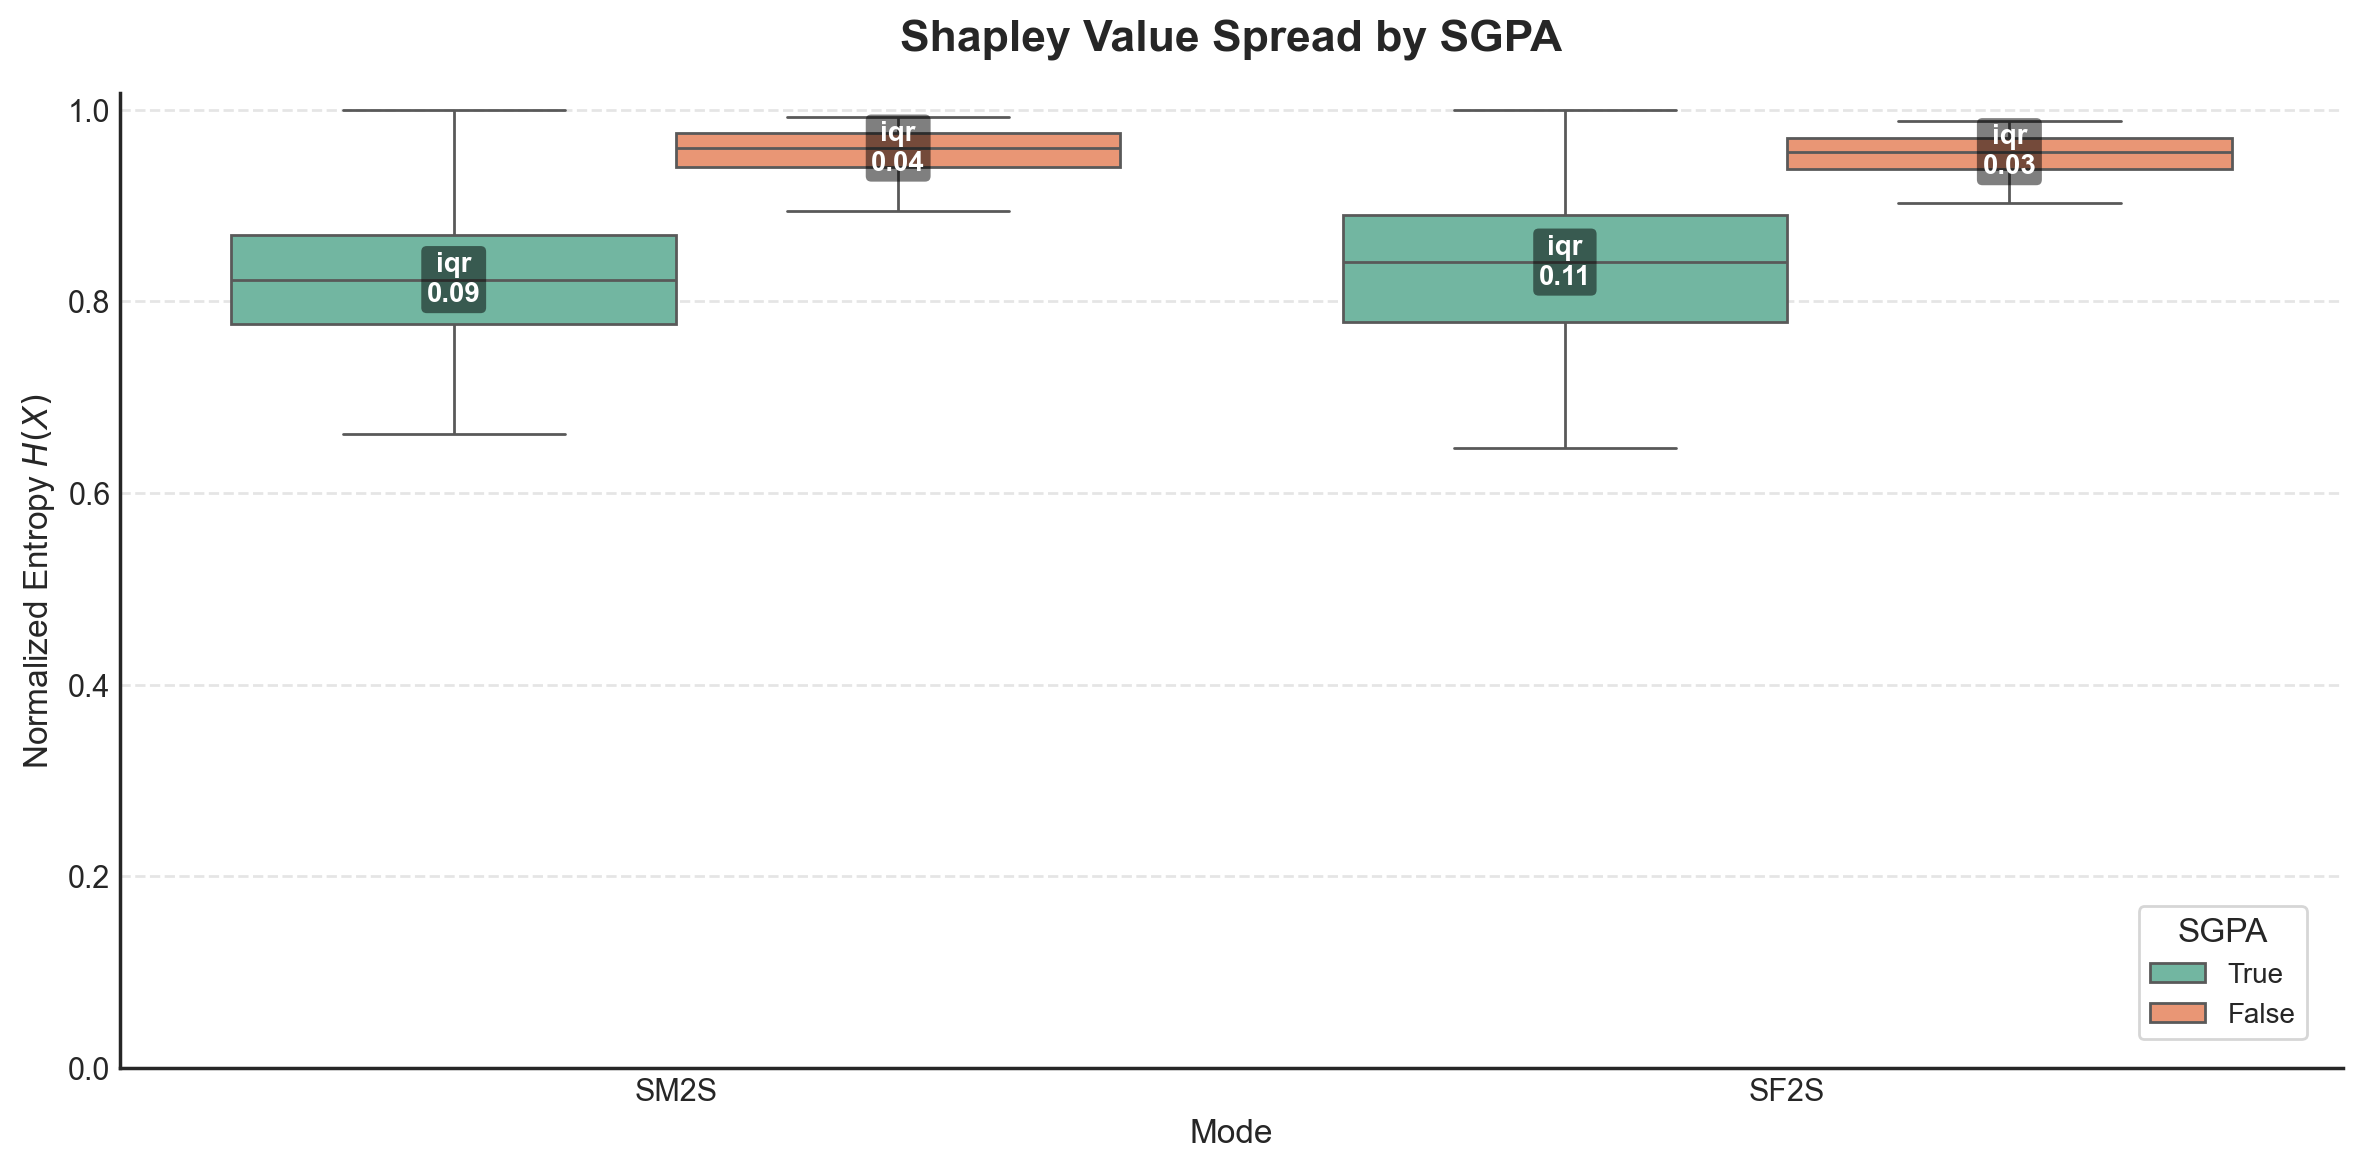

In [20]:
df["sv_entropy"] = df["sv"].apply(calculate_normalized_entropy)
stats = df.groupby("mode")["sv_entropy"].agg(median="median", iqr=lambda x: x.quantile(0.75) - x.quantile(0.25))

plt.figure(figsize=(12, 6))
ax = sns.boxplot(data=df, x="mode", y="sv_entropy", hue="sgpa", palette="Set2", showfliers=False)

stats = df.groupby(["mode", "sgpa"])["sv_entropy"].agg(
    median="median", iqr=lambda x: x.quantile(0.75) - x.quantile(0.25)
)

modes_order = ["SM2S", "SF2S"]
spgas = [True, False]
mode_to_x = {mode: i for i, mode in enumerate(modes_order)}

for (mode, sgpa), row in stats.iterrows():
    if np.isnan(row["median"]):
        continue
    x_pos = mode_to_x[mode] + (spgas.index(sgpa) - 0.5) * 0.4
    ax.text(
        x_pos,
        row["median"],
        f"iqr\n{row['iqr']:.2f}",
        ha="center",
        va="center",
        fontweight="bold",
        size=10,
        color="white",
        bbox={"facecolor": "black", "alpha": 0.5, "edgecolor": "none", "boxstyle": "round,pad=0.2"},
    )

plt.title("Shapley Value Spread by SGPA", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Mode", fontsize=12)
plt.ylabel("Normalized Entropy $H(X)$", fontsize=12)
plt.ylim(bottom=0)
sns.despine(top=True, right=True)
ax.tick_params(axis="both", which="both", length=0)
ax.legend(title="SGPA", title_fontsize=12, fontsize=10, bbox_to_anchor=(0.99, 0.18))
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/sv_entropy_by_mode.png", bbox_inches="tight", dpi=300)

## Over time

In [21]:
results_df["token_pos_idx"] = results_df.groupby(["mode", "sgpa", "row_index"]).cumcount()
results_df["max_idx"] = results_df.groupby(["mode", "sgpa", "row_index"])["token_pos_idx"].transform("max")
results_df.loc[results_df["max_idx"] == 0, "max_idx"] = 1
results_df["normalized_position"] = results_df["token_pos_idx"] / results_df["max_idx"]

In [22]:
sns.set_theme(style="white")

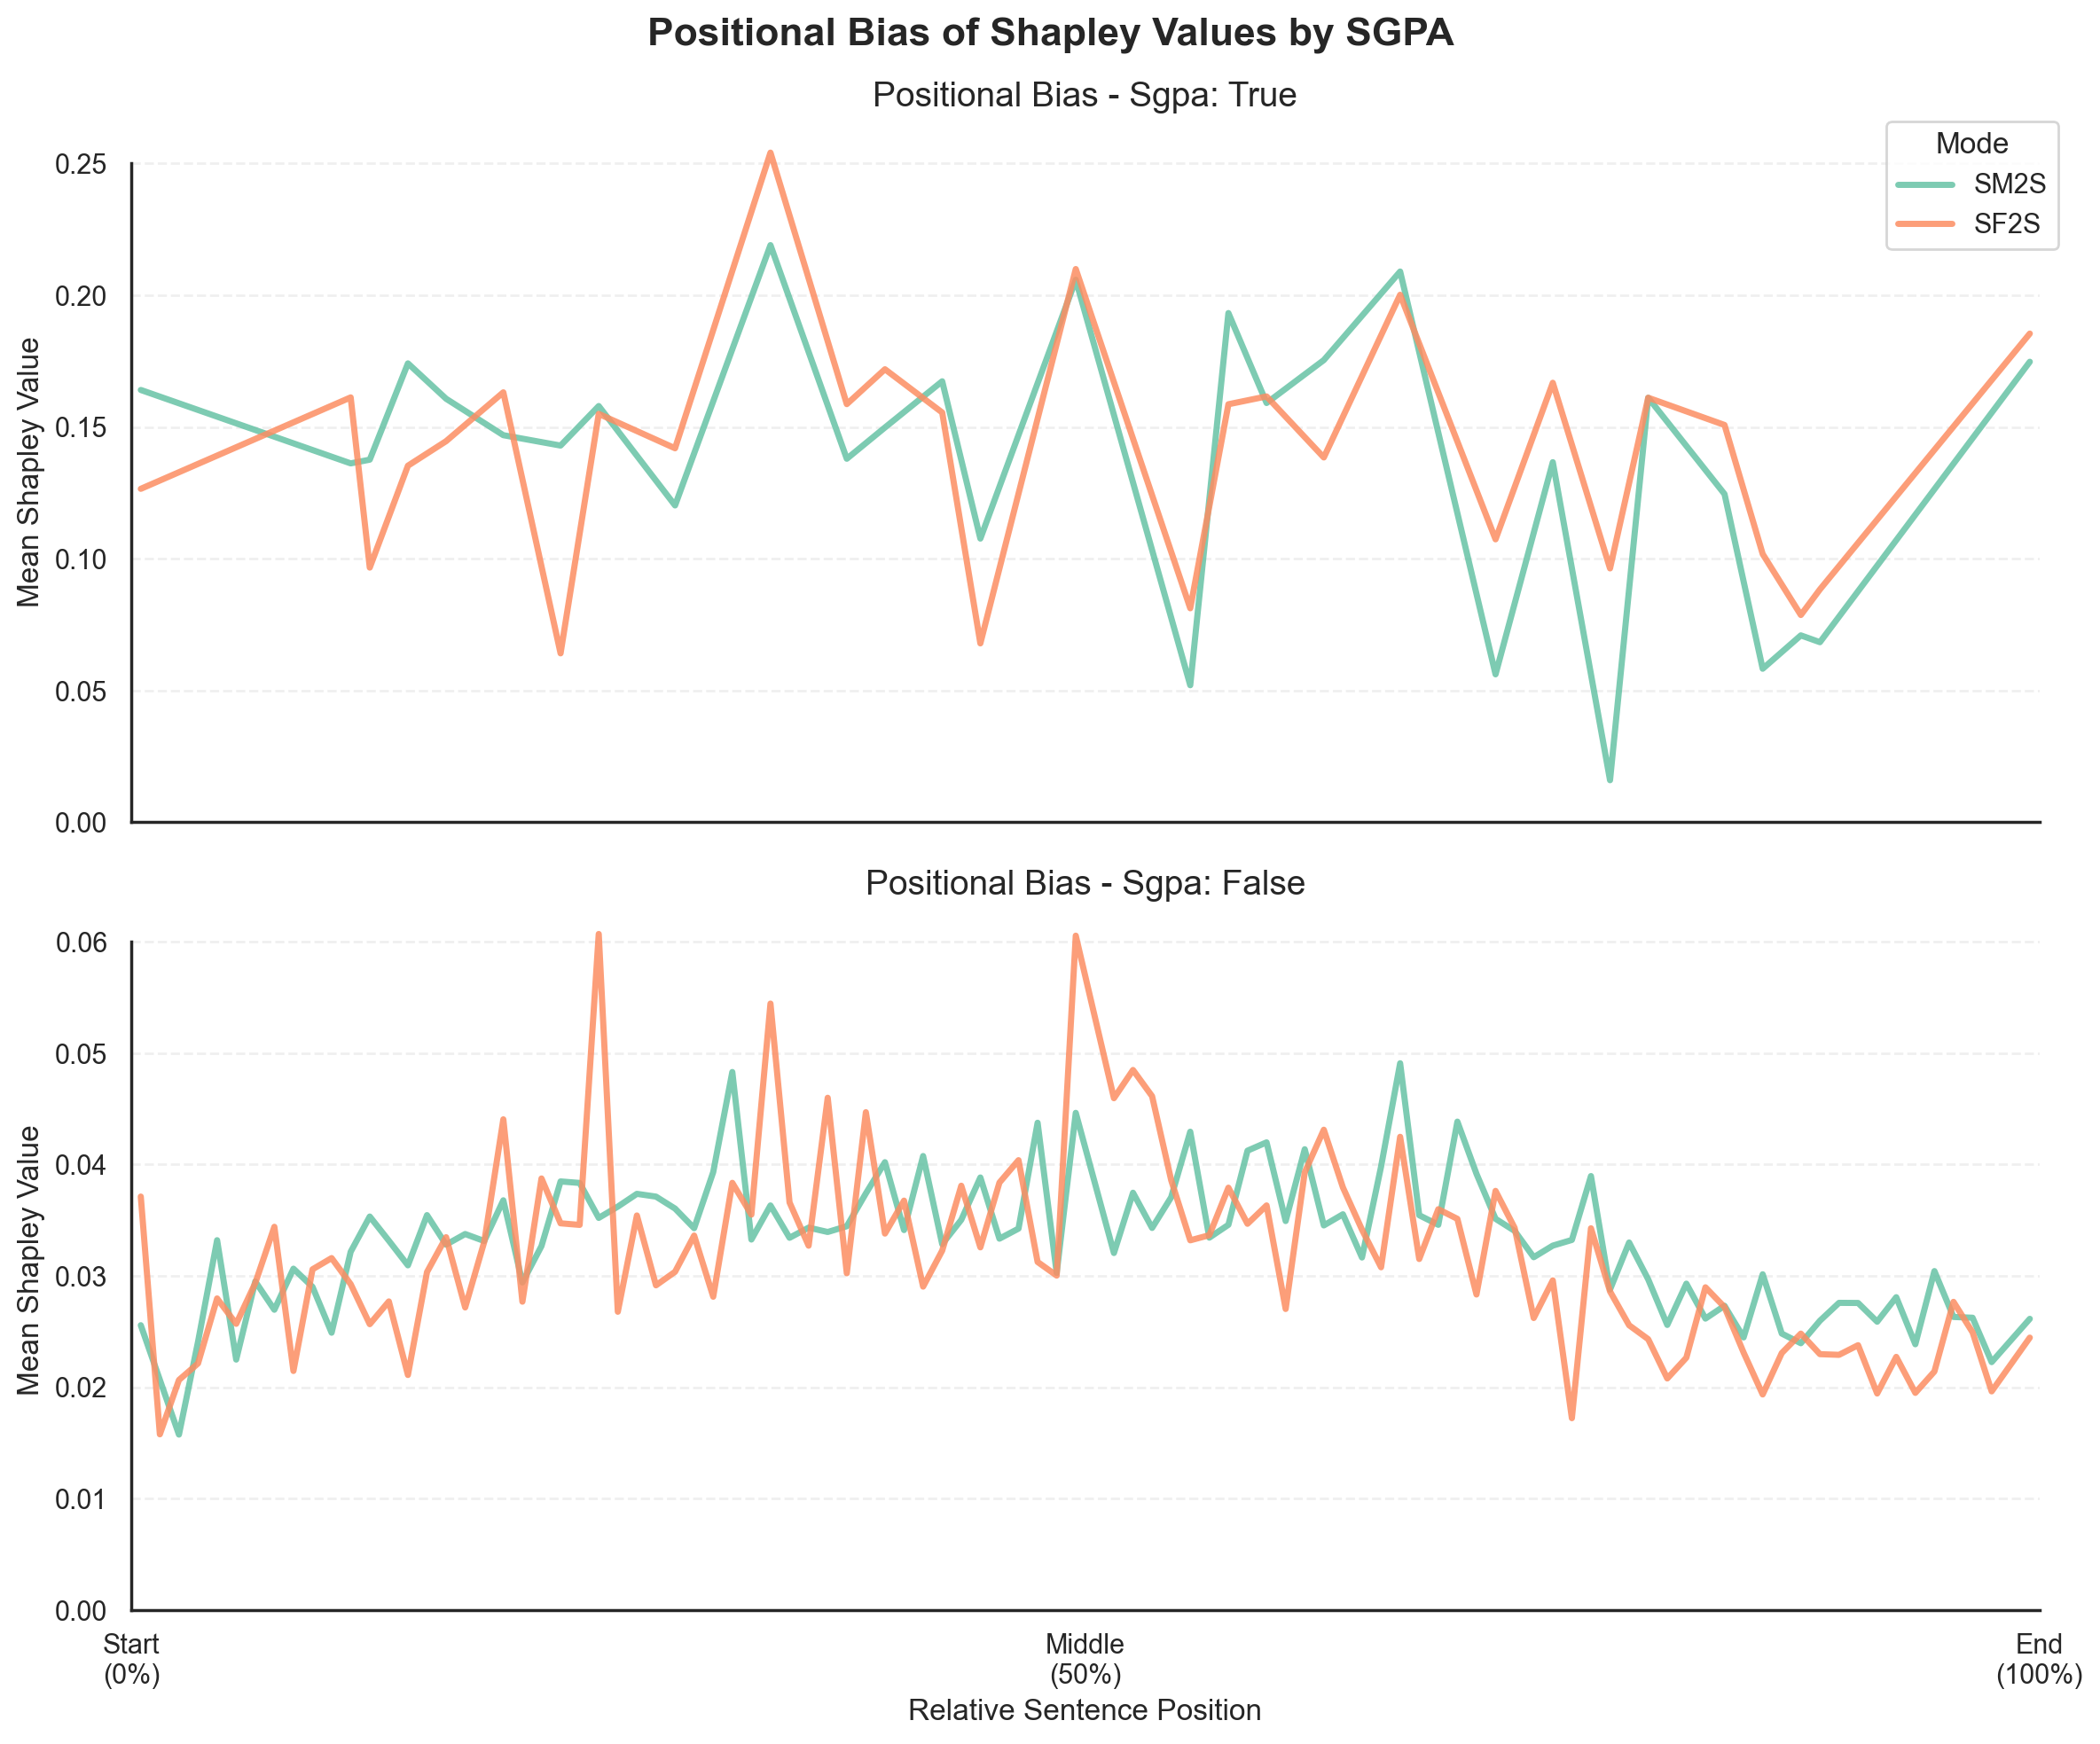

In [ ]:
sgpas = df["sgpa"].unique()
n_langs = len(sgpas)
fig, axes = plt.subplots(n_langs, 1, figsize=(12, 5 * n_langs), sharex=True)
if n_langs == 1:
    axes = [axes]

for i, (ax, sgpa) in enumerate(zip(axes, sgpas)):
    data = results_df[(results_df["sgpa"] == sgpa)]

    plot_attribution_trend(data, n_bins=100, ax=ax, legend=i == 0)
    ax.set_title(f"Positional Bias - Sgpa: {sgpa}", fontsize=14)

fig.suptitle("Positional Bias of Shapley Values by SGPA", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/positional_bias_smooth_1.png", bbox_inches="tight", dpi=300)